In [ ]:
# lib import
import os
import time
import torch
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

# setup
ds_size = 1000000
source_ds_cache_dir = os.path.join(os.getcwd(), "data", "hf-source")

embed_models = [
    "all-MiniLM-L6-v2",
    "sentence-transformers/all-mpnet-base-v2",
    "nomic-ai/nomic-embed-text-v1.5"
    ]
embed_ds_dirnames = []
for name in embed_models:
    embed_ds_dirnames.append(name.split("/")[-1])

ds_pos_results = []

device = "cuda" if torch.cuda.is_available() else "cpu"
print("running on " + device)

running on cuda


# Acquiring the Source Dataset
Using Huggingface's Datasets we can easily load the wikipedia (20231101.en) dataset. Since we are focusing on encyclopedic data, this will serve as the base for testing the dataset generation pipeline.

In [2]:
source_ds_cache_dir = os.path.join(os.getcwd(), "data", "hf-source")
ds = load_dataset("wikimedia/wikipedia", "20231101.en", cache_dir=source_ds_cache_dir)

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/41 [00:00<?, ?it/s]

In [3]:
# verification (optional)
print(f"Dataset length: {len(ds['train'])}")
print(ds['train'][0])
print(ds['train'][-1])

Dataset length: 6407814
{'id': '12', 'url': 'https://en.wikipedia.org/wiki/Anarchism', 'title': 'Anarchism', 'text': 'Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism. Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations. As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as the libertarian wing of the socialist movement (libertarian socialism).\n\nHumans have lived in societies without formal hierarchies long before the establishment of states, realms, or empires. With the rise of organised hierarchical bodies, scepticism toward authority also rose. Although traces of anarchist ideas are found all throughout history, modern anarchism emerged from t

In [4]:
# create subset for dev
ds_shuffled = ds.shuffle(seed=97)
if ds_size > 0:
    ds_subset = ds_shuffled['train'].select(range(ds_size))
else:
    ds_subset = ds_shuffled['train']
    
print(f"Test subset length: {len(ds_subset)}")
print(f"Sample entry: {ds_subset[0]['title']}")

Test subset length: 1000000
Sample entry: Processing delay


# Embedding Generation

In [5]:
embed_ds = []
print("Preparing texts...")
texts = ds_subset['text']

for index, model_name in enumerate(embed_models):
    ds_embed_dir = os.path.join(os.getcwd(), "data", "ds_embed",  embed_ds_dirnames[index], str(ds_size))
    embed_ds.append(ds_subset)

    print("Loading model...")
    model = SentenceTransformer(model_name, trust_remote_code=True, device=device)
    # tokenizer = model.tokenizer
    # print("Tokenizer loaded:")
    # print(tokenizer)
    
    # print("Generating tokens in batches...")
    # tokenization_start = time.time()
    # batch_size = 10000
    # total_samples = len(texts)
    # all_token_ids = []

    # for i in tqdm(range(0, total_samples, batch_size), desc="Tokenizing batches"):
    #     batch_texts = texts[i:i + batch_size]
    #     batch_encoding = tokenizer(
    #         batch_texts,
    #         padding=True,
    #         truncation=True, 
    #         return_tensors=None,
    #         add_special_tokens=True
    #     )
    #     all_token_ids.extend(batch_encoding['input_ids'])
    # tokenization_time = time.time() - tokenization_start
    # print(f"Tokenization took: {tokenization_time:.2f} second(s)")

    # print("Adding raw token ids to embed dataset...")
    # embed_ds[index] = embed_ds[index].add_column("token_ids", all_token_ids)

    # print("Saving dataset with tokens...")
    # embed_ds[index].save_to_disk(ds_embed_dir)

    print("Generating embeddings...")
    embedding_start = time.time()
    
    if(model_name == "nomic-ai/nomic-embed-text-v1.5"):
        batch_encoding = model.encode(texts, show_progress_bar=True, batch_size=16, device=device, prompt="clustering: ")
    else:
        batch_encoding = model.encode(texts, show_progress_bar=True, batch_size=32, device=device)

    embedding_time = time.time() - embedding_start
    print(f"Embedding generation took: {embedding_time:.2f} second(s)")
    
    embed_ds[index] = embed_ds[index].add_column("embeddings", batch_encoding.tolist())

    print("Saving dataset with embeddings...")
    embed_ds[index].save_to_disk(ds_embed_dir)

Preparing texts...
Loading model...
Generating embeddings...


Batches:   0%|          | 0/31250 [00:00<?, ?it/s]

Embedding generation took: 1526.48 second(s)
Saving dataset with embeddings...


Saving the dataset (0/13 shards):   0%|          | 0/1000000 [00:00<?, ? examples/s]

Loading model...
Generating embeddings...


...

<All keys matched successfully>


Generating embeddings...


Batches:   0%|          | 0/62500 [00:00<?, ?it/s]

Embedding generation took: 47555.92 second(s)
Saving dataset with embeddings...


Saving the dataset (0/19 shards):   0%|          | 0/1000000 [00:00<?, ? examples/s]

# Processing


In [6]:
import numpy as np
from numpy import ndarray
from datasets import Dataset, DatasetDict
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA


def prep(data: Dataset | DatasetDict) -> ndarray:
    prep_start = time.time()
    
    # L2-normalization (to euclidean instead of cosine)
    embeddings_array = np.asarray(data, dtype=np.float32)
    embeddings_norm = normalize(embeddings_array, norm="l2", axis=1)

    # PCA red to 50 dims: De-noising and speedup
    pca = PCA(n_components=50, random_state=97, svd_solver="auto", whiten=False)
    data = pca.fit_transform(embeddings_norm)
    
    prep_time = time.time() - prep_start
    print(f"Data preparation took: {prep_time:.2f} seconds")
    
    return data

In [7]:

from sklearn.preprocessing import MinMaxScaler

def normalize_coords(embed_reduced, target_range=(-1, 1)):
    scaler = MinMaxScaler(feature_range=target_range)
    return scaler.fit_transform(embed_reduced)

# Pipeline A (UMAP)
Based on [`knoto`](https://github.com/whatphilipcodes/knoto), this pipeline uses `UMAP` to reduce `sBERT` embeddings into two (spatial) dimensions.

In [8]:
import umap
from datasets import load_from_disk

for dirname in embed_ds_dirnames:
    ds_embed_dir = os.path.join(os.getcwd(), "data", "ds_embed", dirname, str(ds_size))
    ds_pos_dir = os.path.join(os.getcwd(), "data", "ds_pos", dirname, "umap", str(ds_size))

    ds_embed = load_from_disk(ds_embed_dir)
    print(f"Loaded dataset with {len(ds_embed)} entries")

    # collect embeddings
    embeddings_array = prep(ds_embed['embeddings'])
    print(f"Embeddings shape: {embeddings_array.shape}")

    # apply UMAP reduction
    reducer = umap.UMAP(n_components=2, random_state=97, init="pca")
    print("Applying UMAP reduction...")
    reduction_start = time.time()
    embed_reduced = reducer.fit_transform(embeddings_array)
    print(f"2D embeddings shape: {embed_reduced.shape}")
    reduction_time = time.time() - reduction_start
    print(f"UMAP dimensionality reduction took: {reduction_time:.2f} second(s)")

    # apply normalization
    embed_reduced = normalize_coords(embed_reduced)

    # add to ds
    ds_pos = ds_embed.add_column("x", embed_reduced[:, 0].tolist())
    ds_pos = ds_pos.add_column("y", embed_reduced[:, 1].tolist())
    print(f"Final dataset columns: {ds_pos.column_names}")

    # save ds with positions
    ds_pos.save_to_disk(ds_pos_dir)
    ds_pos_results.append(ds_pos_dir)
    print("Dataset with UMAP positions saved successfully!")

Loaded dataset with 1000000 entries
Data preparation took: 19.32 seconds
Embeddings shape: (1000000, 50)
Applying UMAP reduction...


c:\Users\ctechadmin\Documents\Philip\acme-paper\src\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D embeddings shape: (1000000, 2)
UMAP dimensionality reduction took: 1054.20 second(s)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'x', 'y']


Saving the dataset (0/13 shards):   0%|          | 0/1000000 [00:00<?, ? examples/s]

Dataset with UMAP positions saved successfully!


...

Loaded dataset with 1000000 entries
Data preparation took: 42.98 seconds
Embeddings shape: (1000000, 50)
Applying UMAP reduction...


c:\Users\ctechadmin\Documents\Philip\acme-paper\src\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D embeddings shape: (1000000, 2)
UMAP dimensionality reduction took: 1021.09 second(s)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'x', 'y']


Saving the dataset (0/19 shards):   0%|          | 0/1000000 [00:00<?, ? examples/s]

Dataset with UMAP positions saved successfully!


# Pipeline B (t-SNE)
based on the `scikit-learn` implementation of `t-SNE`.

In [12]:
embed_ds_dirnames.remove("all-MiniLM-L6-v2")
print(embed_ds_dirnames)

['all-mpnet-base-v2', 'nomic-embed-text-v1.5']


In [13]:
from openTSNE import TSNE
from datasets import load_from_disk

for dirname in embed_ds_dirnames:
    ds_embed_dir = os.path.join(os.getcwd(), "data", "ds_embed", dirname, str(ds_size))
    ds_pos_dir = os.path.join(os.getcwd(), "data", "ds_pos", dirname, "tsne", str(ds_size))

    # load dataset with embeddings (reuse from UMAP pipeline)
    ds_embed = load_from_disk(ds_embed_dir)
    print(f"Loaded dataset with {len(ds_embed)} entries")

    # collect embeddings
    embeddings_array = prep(ds_embed['embeddings'])
    print(f"Embeddings shape: {embeddings_array.shape}")

    # apply t-SNE reduction using OpenTSNE
    tsne = TSNE(
        n_components=2, 
        random_state=97, 
        initialization="pca",
        n_jobs=-1  # use all available cores
    )
    print("Applying t-SNE reduction...")
    reduction_start = time.time()
    embed_reduced_tsne = tsne.fit(embeddings_array)
    print(f"2D t-SNE embeddings shape: {embed_reduced_tsne.shape}")
    reduction_time = time.time() - reduction_start
    print(f"tSNE dimensionality reduction took: {reduction_time:.2f} second(s)")

    # normalize coords
    embed_reduced_tsne = normalize_coords(embed_reduced_tsne)

    # add to dataset
    ds_pos_tsne = ds_embed.add_column("x", embed_reduced_tsne[:, 0].tolist())
    ds_pos_tsne = ds_pos_tsne.add_column("y", embed_reduced_tsne[:, 1].tolist())
    print(f"Final dataset columns: {ds_pos_tsne.column_names}")

    # save dataset with t-SNE positions
    ds_pos_tsne.save_to_disk(ds_pos_dir)
    ds_pos_results.append(ds_pos_dir)
    print("Dataset with t-SNE positions saved successfully!")

Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Loaded dataset with 1000000 entries
Data preparation took: 42.67 seconds
Embeddings shape: (1000000, 50)
Applying t-SNE reduction...
2D t-SNE embeddings shape: (1000000, 2)
tSNE dimensionality reduction took: 902.79 second(s)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'x', 'y']


Saving the dataset (0/19 shards):   0%|          | 0/1000000 [00:00<?, ? examples/s]

Dataset with t-SNE positions saved successfully!


Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Loaded dataset with 1000000 entries
Data preparation took: 41.48 seconds
Embeddings shape: (1000000, 50)
Applying t-SNE reduction...
2D t-SNE embeddings shape: (1000000, 2)
tSNE dimensionality reduction took: 872.85 second(s)
Final dataset columns: ['id', 'url', 'title', 'text', 'embeddings', 'x', 'y']


Saving the dataset (0/19 shards):   0%|          | 0/1000000 [00:00<?, ? examples/s]

Dataset with t-SNE positions saved successfully!


# Visualization

In [8]:
ds_pos_results = [
    "data\\ds_pos\\all-MiniLM-L6-v2\\tsne\\1000000",
    "data\\ds_pos\\all-MiniLM-L6-v2\\umap\\1000000",
    "data\\ds_pos\\all-mpnet-base-v2\\tsne\\1000000",
    "data\\ds_pos\\all-mpnet-base-v2\\umap\\1000000",
    "data\\ds_pos\\nomic-embed-text-v1.5\\tsne\\1000000",
    "data\\ds_pos\\nomic-embed-text-v1.5\\umap\\1000000",
]

img_dir = os.path.join(os.getcwd(), "img")
os.makedirs(img_dir, exist_ok=True)

ds_pos = []

Loading data...
Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_tsne_1000000_20250912T151518.pdf


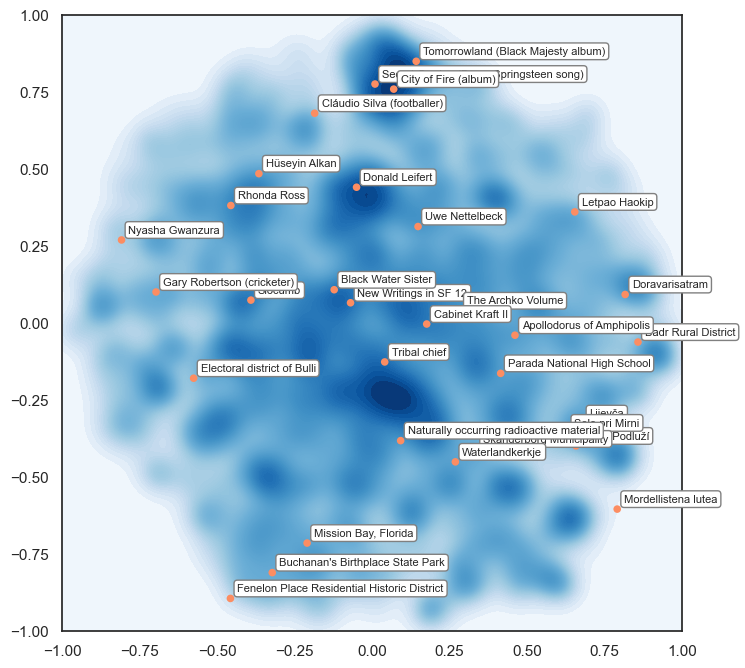

Loading data...
Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_umap_1000000_20250912T153719.pdf


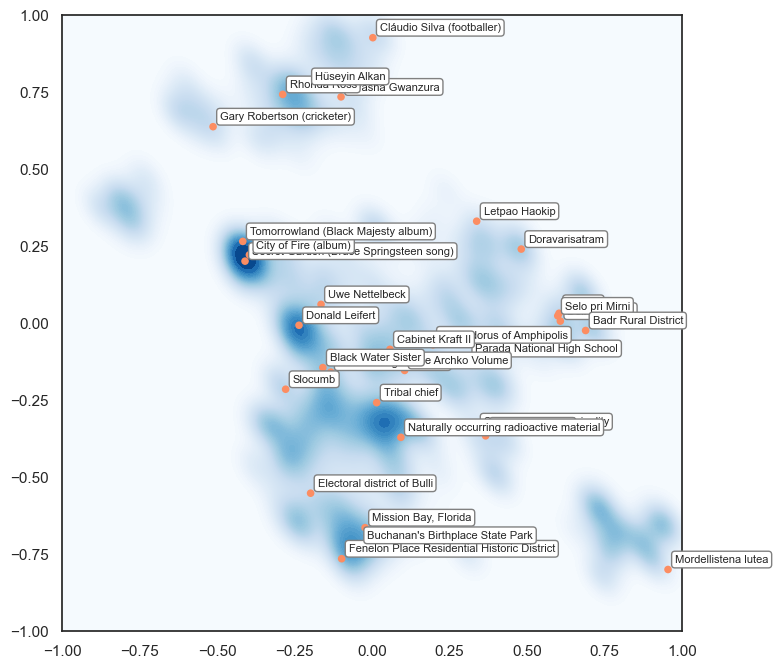

Loading data...


Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_tsne_1000000_20250912T160034.pdf


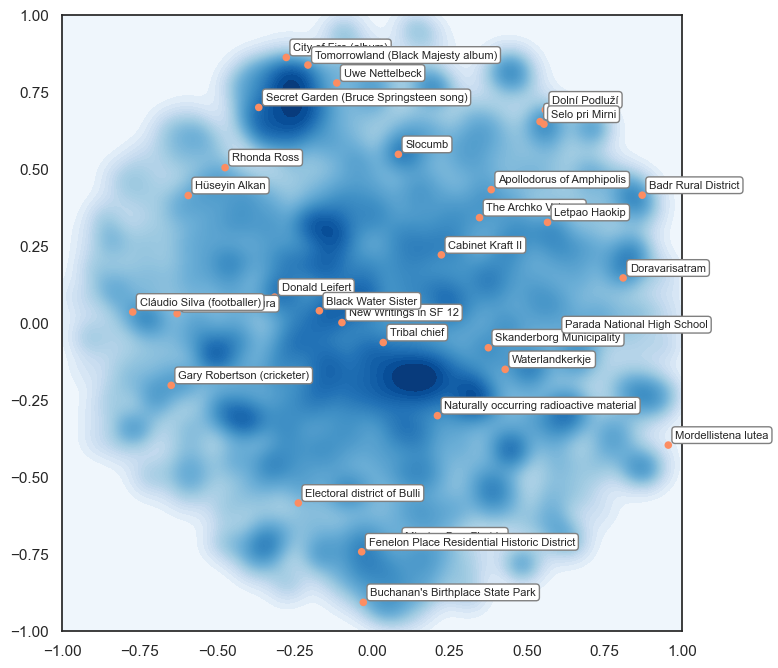

Loading data...


Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_umap_1000000_20250912T162239.pdf


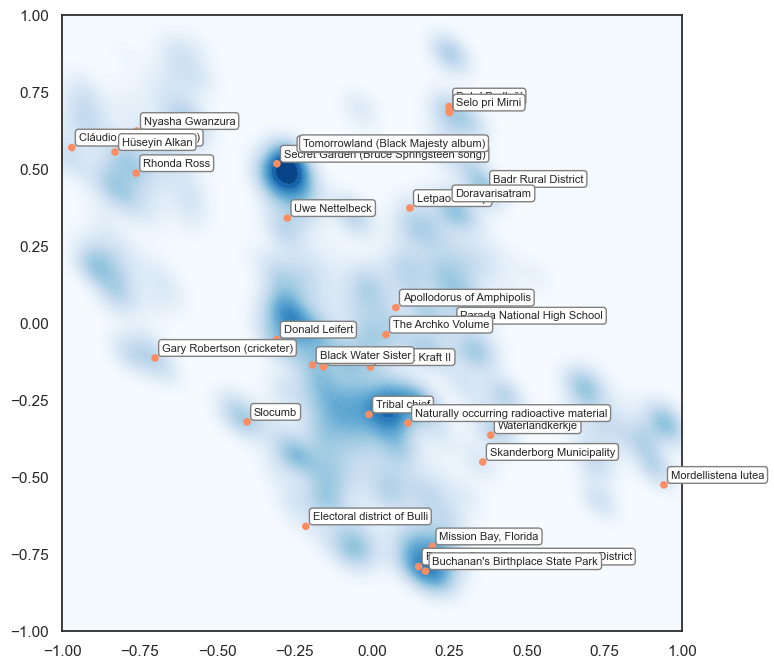

Loading data...


Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\nomic-embed-text-v1.5_tsne_1000000_20250912T164556.pdf


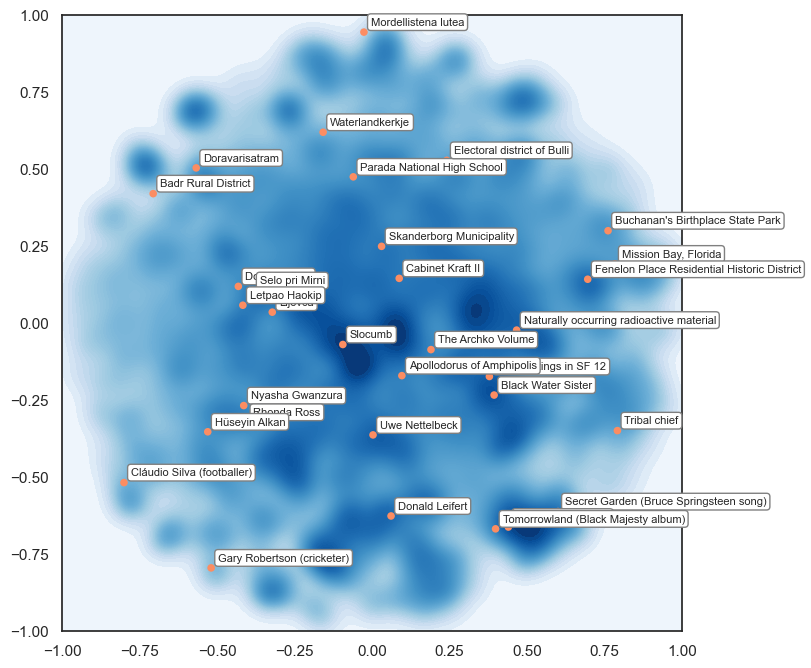

Loading data...


Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Assigning cols...
Running kdplot()...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\nomic-embed-text-v1.5_umap_1000000_20250912T170900.pdf


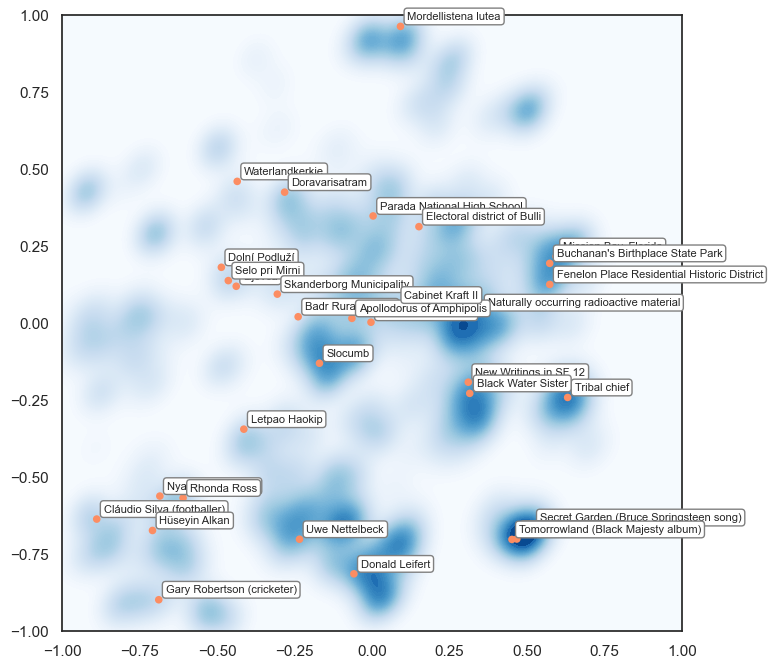

In [ ]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from datetime import datetime

teaser_data = []


for dir in ds_pos_results:
    print("Loading data...")

    ds_pos = load_from_disk(dir)
    teaser_data.append(ds_pos)

    print("Assigning cols...")
    xs = ds_pos["x"]
    ys = ds_pos["y"]
    labels = ds_pos["title"]

    plt.figure(figsize=(8, 8))  # Square figure size
    sns.set_theme(style="white")

    random.seed(97)
    random_indices = set(random.sample(range(len(xs)), min(32, len(xs))))

    # Separate labeled and unlabeled points
    unlabeled_x = [x for i, x in enumerate(xs) if i not in random_indices]
    unlabeled_y = [y for i, y in enumerate(ys) if i not in random_indices]

    labeled_x = [x for i, x in enumerate(xs) if i in random_indices]
    labeled_y = [y for i, y in enumerate(ys) if i in random_indices]

    palette = sns.color_palette("Set2")

    print("Running kdplot()...")
    # KDE density plot for unlabeled points
    sns.kdeplot(
        x=unlabeled_x, y=unlabeled_y,
        fill=True,
        thresh=0,
        levels=100,
        cmap="Blues"
    )

    print("Running scatterplot()...")
    # Scatter for labeled points
    sns.scatterplot(x=labeled_x, y=labeled_y, s=30, color=palette[1], edgecolor='none', zorder=3)

    # Annotate labeled points
    for i, (x, y, label) in enumerate(zip(xs, ys, labels)):
        if i in random_indices:
            plt.annotate(
                label,
                (x, y),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=1.0, edgecolor='gray')
            )

    # Set fixed square aspect ratio and limits
    plt.xlim(-1.0, 1.0)
    plt.ylim(-1.0, 1.0)

    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
    dir_parts = dir.replace(os.getcwd(), "").strip(os.sep).split(os.sep)
    filename = f"{dir_parts[2]}_{dir_parts[3]}_{dir_parts[4]}_{timestamp}.pdf"
    filepath = os.path.join(img_dir, filename)

    # Save as PDF
    plt.savefig(filepath, format='pdf', bbox_inches='tight')
    print(f"Saved plot to: {filepath}")

    plt.show()


In [ ]:
for dir in ds_pos_results:
    print("Loading data...")

    print("loading from:", dir)

    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
    dir_parts = dir.replace(os.getcwd(), "").strip(os.sep).split(os.sep)
    filename = f"{dir_parts[2]}_{dir_parts[3]}_{dir_parts[4]}_{timestamp}.png"
    filepath = os.path.join(img_dir, filename)
    print(f"Saved plot to: {filepath}")

Loading data...
Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_tsne_1000000_20250912T171816.png


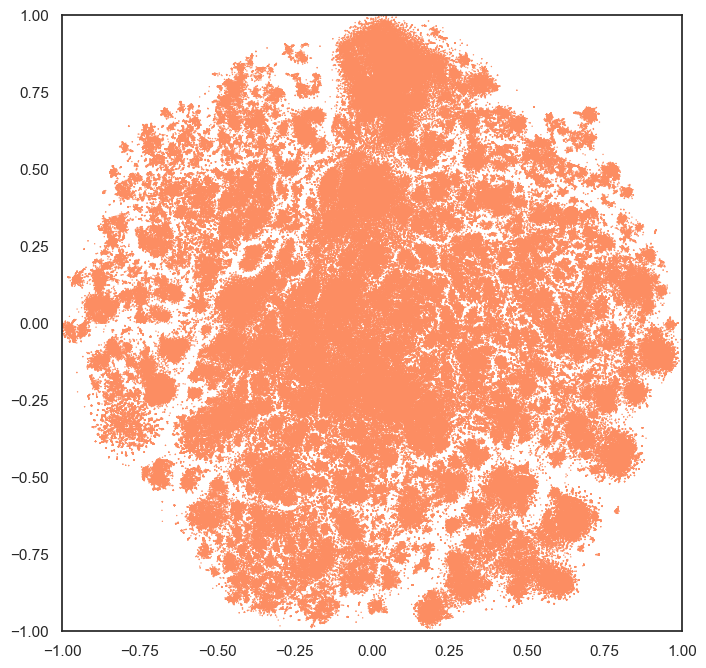

Loading data...
Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-MiniLM-L6-v2_umap_1000000_20250912T171832.png


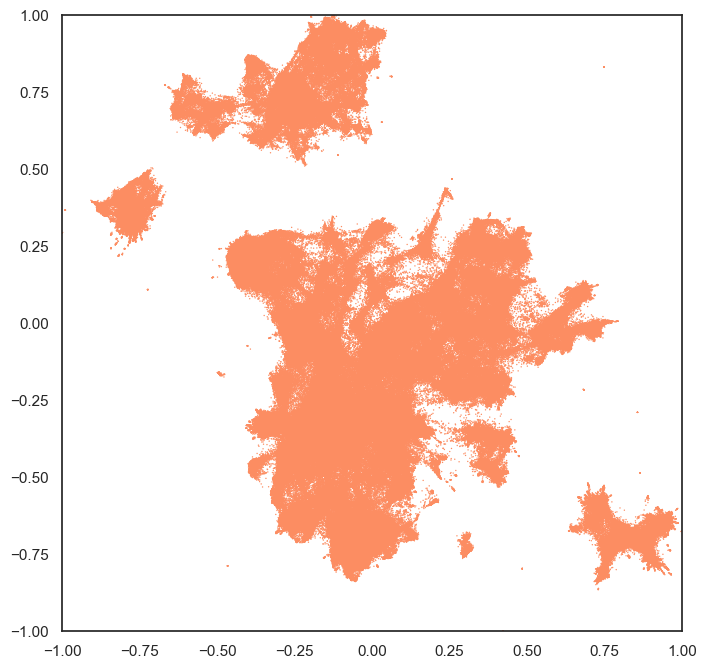

Loading data...


Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_tsne_1000000_20250912T171848.png


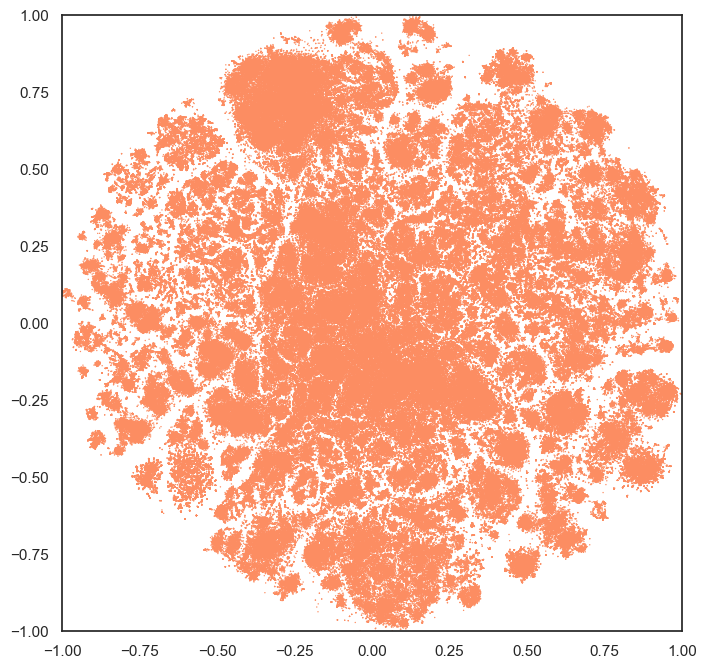

Loading data...


Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\all-mpnet-base-v2_umap_1000000_20250912T171904.png


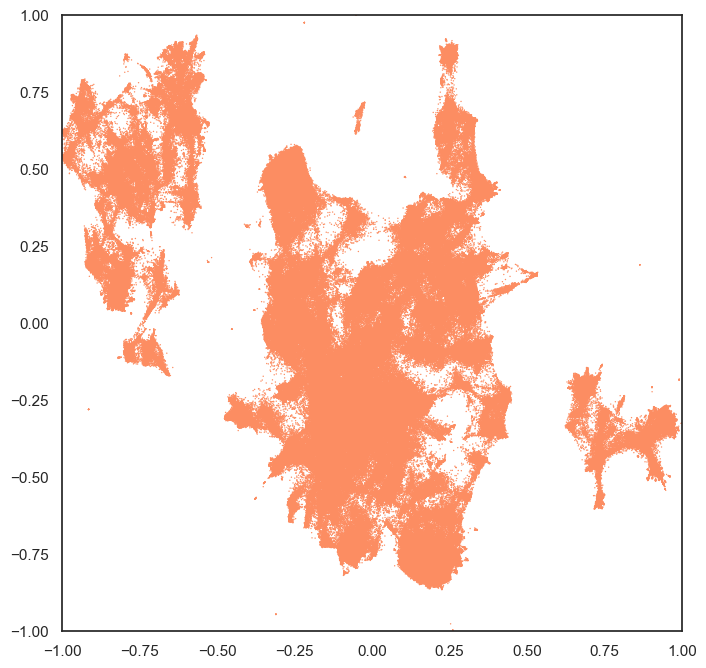

Loading data...


Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\nomic-embed-text-v1.5_tsne_1000000_20250912T171920.png


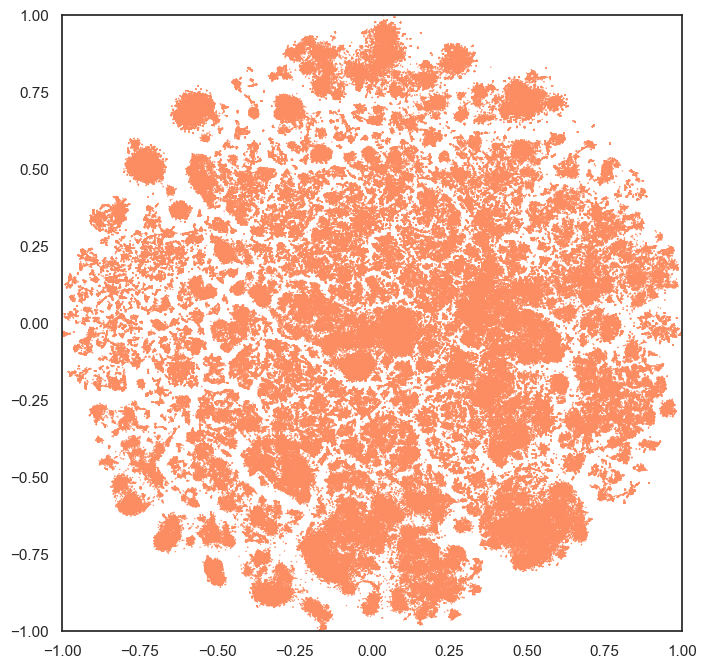

Loading data...


Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Assigning cols...
Running scatterplot()...
Saved plot to: c:\Users\ctechadmin\Documents\Philip\acme-paper\src\img\nomic-embed-text-v1.5_umap_1000000_20250912T171936.png


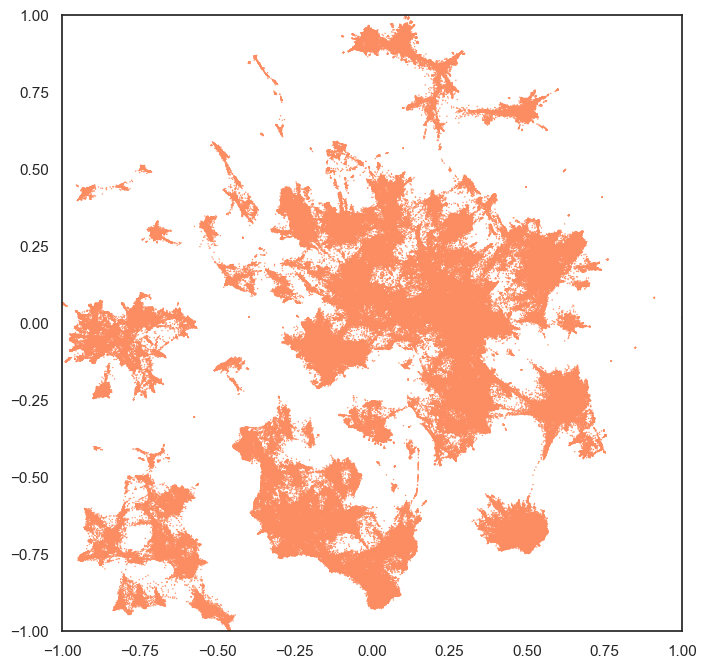

In [ ]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

img_dir = os.path.join(os.getcwd(), "img")
os.makedirs(img_dir, exist_ok=True)

teaser_data = []
ds_pos = []

for dir in ds_pos_results:
    print("Loading data...")

    ds_pos = load_from_disk(dir)
    teaser_data.append(ds_pos)

    print("Assigning cols...")
    xs = ds_pos["x"]
    ys = ds_pos["y"]

    plt.figure(figsize=(8, 8))  # Square figure size
    sns.set_theme(style="white")

    palette = sns.color_palette("Set2")

    print("Running scatterplot()...")
    # Scatter plot with 1px points
    sns.scatterplot(x=xs, y=ys, s=1, color=palette[1], edgecolor='none')

    # Set fixed square aspect ratio and limits
    plt.xlim(-1.0, 1.0)
    plt.ylim(-1.0, 1.0)

    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
    dir_parts = dir.replace(os.getcwd(), "").strip(os.sep).split(os.sep)
    filename = f"{dir_parts[2]}_{dir_parts[3]}_{dir_parts[4]}_{timestamp}.png"
    filepath = os.path.join(img_dir, filename)

    # Save as PNG
    plt.savefig(filepath, format='png', bbox_inches='tight', dpi=300)
    print(f"Saved plot to: {filepath}")

    plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

img_dir = os.path.join(os.getcwd(), "img")
os.makedirs(img_dir, exist_ok=True)

sns.set_theme(style="white")

# Labels for 6 subplots
labels = ['(a-umap)', '(b-umap)', '(c-umap)', '(a-tsne)', '(b-tsne)', '(c-tsne)']

# 2 rows, 3 columns
f, axes = plt.subplots(2, 3, figsize=(24, 16), sharex=True, sharey=True)
axes = axes.flatten()

# Use 3 distinct cubehelix starts for the first row and repeat for the second
cubehelix_starts = [0, 1.0, 2.0, 0, 1.0, 2.0]

for ax, ds, label, s in zip(axes, teaser_data, labels, cubehelix_starts):
    x = ds['x']
    y = ds['y']
    
    # Cubehelix colormap
    cmap = sns.cubehelix_palette(start=s, rot=0.5, light=1, as_cmap=True)
    
    # KDE plot
    sns.kdeplot(
        x=x, y=y,
        cmap=cmap,
        fill=True,
        clip=(-1.0, 1.0),
        thresh=0.1,
        levels=15,
        ax=ax,
    )
    
    ax.set_axis_off()
    ax.text(-0.97, -0.96, label, fontsize=14, fontweight='bold')

ax.set(xlim=(-1.0, 1.0), ylim=(-1.0, 1.0))
f.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.05, hspace=0.05)

# Generate filename with timestamp
timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")
filename = f"teaser_{timestamp}.pdf"
filepath = os.path.join(img_dir, filename)

# Save as PDF
plt.savefig(filepath, format='pdf', bbox_inches='tight')
print(f"Saved plot to: {filepath}")

plt.show()

In [6]:
"""
from datasets import load_from_disk, DatasetDict

# Map directories to custom names
dirs = {
    "data\\ds_pos\\all-MiniLM-L6-v2\\tsne\\1000000": "wikipos.all_MiniLM_L6_v2_tsne",
    "data\\ds_pos\\all-MiniLM-L6-v2\\umap\\1000000": "wikipos.all_MiniLM_L6_v2_umap",
    "data\\ds_pos\\all-mpnet-base-v2\\tsne\\1000000": "wikipos.all_mpnet_base_v2_tsne",
    "data\\ds_pos\\all-mpnet-base-v2\\umap\\1000000": "wikipos.all_mpnet_base_v2_umap",
    "data\\ds_pos\\nomic-embed-text-v1.5\\tsne\\1000000": "wikipos.nomic_embed_text_v1_5_tsne",
    "data\\ds_pos\\nomic-embed-text-v1.5\\umap\\1000000": "wikipos.nomic_embed_text_v1_5_umap",
}

# Load and rename
combined = DatasetDict({
    name: load_from_disk(path) for path, name in dirs.items()
})

# Remove unwanted column from all subsets
for name, ds in combined.items():
    if "token_ids" in ds.column_names:
        combined[name] = ds.remove_columns("token_ids")

# Verify structure and samples
print(combined)
for name in combined:
    print(name, combined[name][:2])

# Upload
combined.push_to_hub("whatphiliptrains/wikipos")
"""

from datasets import load_from_disk

dirs = {
    "data/ds_pos/all-MiniLM-L6-v2/tsne/1000000": "all_MiniLM_L6_v2_tsne",
    "data/ds_pos/all-MiniLM-L6-v2/umap/1000000": "all_MiniLM_L6_v2_umap",
    "data/ds_pos/all-mpnet-base-v2/tsne/1000000": "all_mpnet_base_v2_tsne",
    "data/ds_pos/all-mpnet-base-v2/umap/1000000": "all_mpnet_base_v2_umap",
    "data/ds_pos/nomic-embed-text-v1.5/tsne/1000000": "nomic_embed_text_v1_5_tsne",
    "data/ds_pos/nomic-embed-text-v1.5/umap/1000000": "nomic_embed_text_v1_5_umap",
}

for path, config_name in dirs.items():
    ds = load_from_disk(path)
    if "token_ids" in ds.column_names:
        ds = ds.remove_columns("token_ids")
    ds.push_to_hub("whatphiliptrains/wikipos", config_name=config_name)



Uploading the dataset shards:   0%|          | 0/13 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/77 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/77 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/77 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/77 [00:00<?, ?ba/s]

...

Creating parquet from Arrow format:   0%|          | 0/53 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/53 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/53 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/53 [00:00<?, ?ba/s]

README.md: 0.00B [00:00, ?B/s]